In [1]:
import numpy as np
import pandas as pd
from datatools import *
import matplotlib.pyplot as plt
import seaborn as sns

### 策略

In [2]:
start_date = '2019-01-01'
end_date = '2026-06-30'
allstocks = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstocks = allstocks[~allstocks['ts_code'].str.contains('BJ')].ts_code.tolist()
load_start = (pd.Timestamp(start_date) - pd.DateOffset(years=1)).strftime('%Y-%m-%d')
price = get_price(codes=allstocks, start_date=load_start, end_date=end_date)
price['daily_return'] = price['close']/price['pre_close'] - 1
price['next_open'] = price.groupby('ts_code')['open'].shift(-1)
price = price.sort_values(by=['ts_code', 'trade_date']).reset_index(drop=True)

### rsrs

In [ ]:
# ── 构建矩阵 ──────────────────────────────────────────────────────────────
dates = np.sort(price['trade_date'].unique())
universe = np.sort(price['ts_code'].unique())

high_pivot = price.pivot(index='trade_date', columns='ts_code', values='high').reindex(index=dates, columns=universe)
low_pivot = price.pivot(index='trade_date', columns='ts_code', values='low').reindex(index=dates, columns=universe)

n_dates, n_stocks = len(dates), len(universe)
print(f'矩阵: {n_dates} 交易日 × {n_stocks} 只股票')
N=18
M=600
cov_xy = high_pivot.rolling(N, min_periods=2).cov(low_pivot)
var_x = low_pivot.rolling(N, min_periods=2).var()
var_y = high_pivot.rolling(N, min_periods=2).var()
slope = cov_xy / var_x
r2 = (cov_xy ** 2) / (var_x * var_y)
slope_zscore = (slope - slope.rolling(M, min_periods=2).mean()) / slope.rolling(M, min_periods=2).std()
rsrs = slope*r2*slope_zscore
rsrs = rsrs.loc[start_date:end_date]
rsrs = rsrs.stack().reset_index().rename(columns={0:'rsrs'})

矩阵: 4955 交易日 × 5489 只股票


### 最低点&MACD&BOLL策略

In [3]:
price['row_idx'] = price.groupby('ts_code').cumcount()
g = price.groupby('ts_code')

# 条件1: 过去15天最低收盘价 == 过去180天最低收盘价
price['min_close_15'] = g['close'].rolling(15).min().reset_index(level=0, drop=True)
price['min_close_180'] = g['close'].rolling(180).min().reset_index(level=0, drop=True)
price['cond1'] = price['min_close_15'] == price['min_close_180']

# 条件2: 过去5天最低价 < 布林带下界 (默认20日, 2倍标准差)
price['ma20'] = g['close'].rolling(20).mean().reset_index(level=0, drop=True)
price['std20'] = g['close'].rolling(20).std().reset_index(level=0, drop=True)
price['lower_band'] = price['ma20'] - 2 * price['std20']
price['low_below_band'] = price['low'] < price['lower_band']
price['cond2'] = g['low_below_band'].rolling(15).max().reset_index(level=0, drop=True) > 0

# 条件3: MACD由绿转红 (柱状值今日大于0，昨日小于等于0)
price['ema12'] = g['close'].ewm(span=12, adjust=False).mean().reset_index(level=0, drop=True)
price['ema26'] = g['close'].ewm(span=26, adjust=False).mean().reset_index(level=0, drop=True)
price['dif'] = price['ema12'] - price['ema26']
price['dea'] = g['dif'].ewm(span=9, adjust=False).mean().reset_index(level=0, drop=True)
price['macd_hist'] = (price['dif'] - price['dea']) * 2
price['cond3'] = (price['macd_hist'] > 0) & (g['macd_hist'].shift(1) < 0)

price['cond4'] = g['macd_hist'].shift(1).rolling(15).max().reset_index(level=0, drop=True) < 0

price['signal'] = price['cond1'] & price['cond2'] & price['cond3'] & price['cond4']

In [4]:
trade_records = price[price['signal']]
trade_records = trade_records.merge(
    price[['ts_code', 'row_idx', 'trade_date', 'next_open']], 
    on=['ts_code', 'row_idx'], suffixes=('', '_buy')
).rename(columns={'trade_date_buy': 'buy_date', 'next_open_buy': 'buy_price'})

trade_records['sell_idx'] = trade_records['row_idx'] + 20
trade_records = trade_records.merge(
    price[['ts_code', 'row_idx', 'trade_date', 'next_open']], 
    left_on=['ts_code', 'sell_idx'], 
    right_on=['ts_code', 'row_idx'],
    suffixes=('', '_sell')
).rename(columns={'trade_date_sell': 'sell_date', 'next_open_sell': 'sell_price'})
trade_records = trade_records[['ts_code', 'buy_date', 'sell_date', 'buy_price', 'sell_price']].dropna().reset_index(drop=True)

In [ ]:
st = get_st(codes=allstocks, start_date=load_start, end_date=end_date)
df2_keys_set = set(zip(st ['trade_date'], st['ts_code']))
df1_keys_tuples = list(zip(trade_records['buy_date'], trade_records['ts_code']))
mask = [tup not in df2_keys_set for tup in df1_keys_tuples]
trade_records = trade_records[mask]
trade_records['returns'] = trade_records.eval('sell_price/buy_price-1')
trade_records = trade_records[trade_records.buy_date.dt.month!=4]
trade_records = trade_records[trade_records.buy_date.dt.month!=3]

In [27]:
metrics, df_res = strategy_metrics(price[['trade_date', 'ts_code','daily_return']], start_date='2022-01-01', end_date='2024-09-23', trade_records = trade_records, cost=0, benchmark='000001.SH')

In [28]:
metrics

{'sharpe_ratio': np.float64(0.42684625677536514),
 'max_drawdown': np.float64(-0.11996628255542863),
 'win_rate': np.float64(0.6317431504906688),
 'information_ratio': np.float64(1.3022313780203618)}

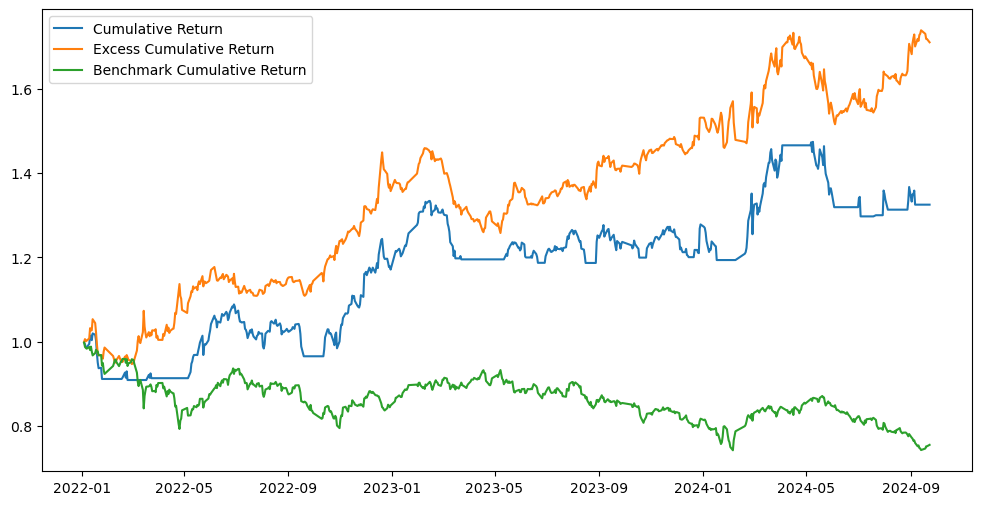

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df_res['trade_date'], df_res['cum_nav'], label='Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_excess_nav'], label='Excess Cumulative Return')
plt.plot(df_res['trade_date'], df_res['cum_bench_nav'], label='Benchmark Cumulative Return')
plt.legend()
plt.show()